In [6]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm prophet statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
df = pd.read_csv("retail_store_inventory.csv")
print(df.head())


         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autumn  
1           

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())


(73100, 15)
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64
       Inventory Level    Units Sold  Units Ordered  Demand Forecast  \
count     73100.000000  73100.000000   73100.000000     73100.000000   
mean   

In [8]:

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and day of week
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek

print(df[['Date', 'month', 'dayofweek']].head())

# Lag features for sales (Units Sold)
for lag in [1, 7, 14]:
    df[f'sales_lag_{lag}'] = df.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(lag)

# Rolling mean features for sales
for win in [7, 14]:
    df[f'sales_roll_mean_{win}'] = df.groupby(['Store ID', 'Product ID'])['Units Sold'].transform(
        lambda x: x.rolling(win).mean()
    )



        Date  month  dayofweek
0 2022-01-01      1          5
1 2022-01-01      1          5
2 2022-01-01      1          5
3 2022-01-01      1          5
4 2022-01-01      1          5


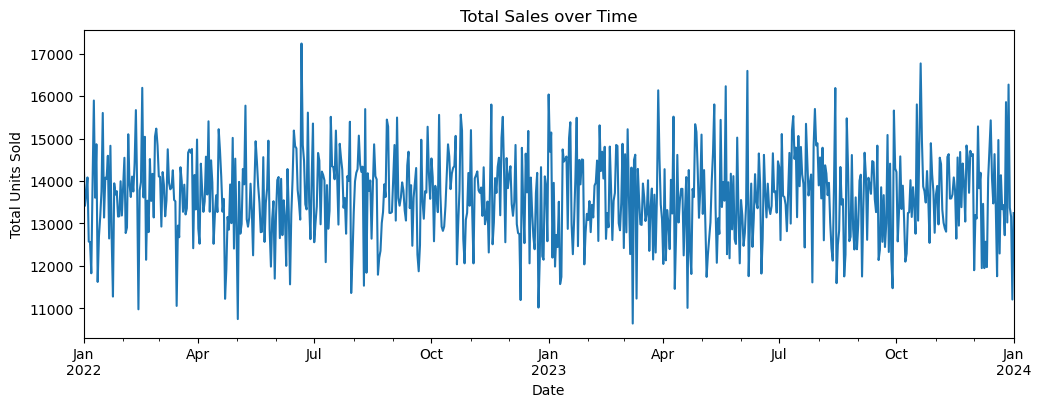

In [10]:
# Plot total sales (Units Sold) over time
df.groupby('Date')['Units Sold'].sum().plot(figsize=(12,4))
plt.title('Total Sales over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.show()

# ------------------------------
# Train/Test Split
# ------------------------------
# Train/Test Split
train = df[df['Date'] < '2022-12-01']
test  = df[df['Date'] >= '2022-12-01']

# Define features
features = [
    'month', 'dayofweek',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
    'sales_roll_mean_7', 'sales_roll_mean_14'
]

# Drop NaN rows from lag/rolling features
train = train.dropna(subset=features + ['Units Sold'])
test  = test.dropna(subset=features + ['Units Sold'])

# Create X/y sets
X_train, y_train = train[features], train['Units Sold']
X_test, y_test   = test[features], test['Units Sold']



In [18]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prophet requires columns 'ds' (datetime) and 'y' (target)
prophet_df = train[['Date', 'Units Sold']].rename(columns={'Date': 'ds', 'Units Sold': 'y'})

m = Prophet()
m.fit(prophet_df)

# ---- FIX: use number of unique test dates, not len(test) ----
n_days = test['Date'].nunique()
future = m.make_future_dataframe(periods=n_days)
forecast = m.predict(future)

# Aggregate test actuals by date
y_test_daily = test.groupby('Date')['Units Sold'].sum().reset_index()

# Align Prophet predictions with the same daily dates
forecast_test = forecast[forecast['ds'].isin(y_test_daily['Date'])]
prophet_preds = forecast_test['yhat'].values

# Ensure both arrays have the same length
assert len(prophet_preds) == len(y_test_daily), "Mismatch in lengths!"

# Evaluation
mae_prophet = mean_absolute_error(y_test_daily['Units Sold'], prophet_preds)
rmse_prophet = np.sqrt(mean_squared_error(y_test_daily['Units Sold'], prophet_preds))

print(f"Prophet - MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}")



10:24:10 - cmdstanpy - INFO - Chain [1] start processing
10:24:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 13452.91, RMSE: 13494.95


📊 XGBoost Results
MAE   : 81.94
RMSE  : 102.65
SMAPE : 68.15%

📊 Prophet Results
MAE   : 13452.91
RMSE  : 13494.95
SMAPE : 195.91%


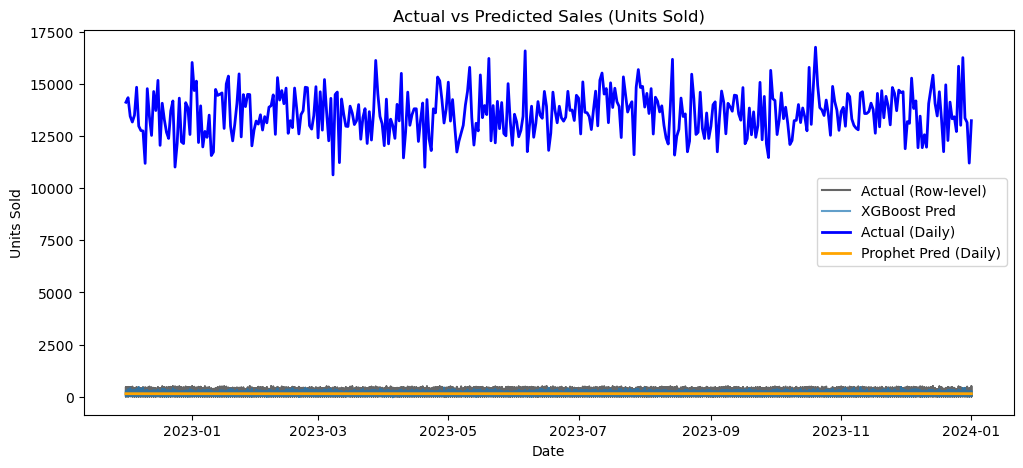

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- Safe SMAPE function (handles divide-by-zero) ---
def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# ---------------------------
# XGBoost Evaluation (row-level)
# ---------------------------
mae_xgb = mean_absolute_error(y_test, preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds))
smape_xgb = smape(y_test.values, preds)

print("📊 XGBoost Results")
print(f"MAE   : {mae_xgb:.2f}")
print(f"RMSE  : {rmse_xgb:.2f}")
print(f"SMAPE : {smape_xgb:.2f}%")

# ---------------------------
# Prophet Evaluation (daily-level)
# ---------------------------
# 1. Aggregate actuals by date
y_test_daily = test.groupby('Date')['Units Sold'].sum().reset_index()

# 2. Align Prophet predictions with daily dates
forecast_test = forecast[forecast['ds'].isin(y_test_daily['Date'])]
prophet_preds = forecast_test['yhat'].values

# 3. Metrics on daily totals
mae_prophet = mean_absolute_error(y_test_daily['Units Sold'], prophet_preds)
rmse_prophet = np.sqrt(mean_squared_error(y_test_daily['Units Sold'], prophet_preds))
smape_prophet = smape(y_test_daily['Units Sold'].values, prophet_preds)

print("\n📊 Prophet Results")
print(f"MAE   : {mae_prophet:.2f}")
print(f"RMSE  : {rmse_prophet:.2f}")
print(f"SMAPE : {smape_prophet:.2f}%")

# ---------------------------
# Plot Actual vs Predictions
# ---------------------------
plt.figure(figsize=(12,5))

# XGBoost: row-level predictions
plt.plot(test['Date'], y_test, label='Actual (Row-level)', color='black', alpha=0.6)
plt.plot(test['Date'], preds, label='XGBoost Pred', alpha=0.7)

# Prophet: daily aggregated predictions
plt.plot(y_test_daily['Date'], y_test_daily['Units Sold'], label='Actual (Daily)', color='blue', linewidth=2)
plt.plot(y_test_daily['Date'], prophet_preds, label='Prophet Pred (Daily)', color='orange', linewidth=2)

plt.legend()
plt.title('Actual vs Predicted Sales (Units Sold)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()


